# GRIT Cross-Dataset Analysis: Attention Sinks in Graph Transformers

This notebook loads trained GRIT models and precomputed diagnostics:

1. **Fig 1 — Context Length Sweep** (Barbero Fig 5 analogue) — Peptides quartiles binned by node count
2. **Fig 2 — Layer-wise diagnostics** per quartile
3. **Fig 3 — VNode vs No-VNode** on ZINC
4. **Fig 4 — ZINC vs Peptides** layer-wise comparison

Training was done via `scripts/run_experiment.py` on EC2. This notebook is analysis-only.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath('..'))

import numpy as np
import matplotlib.pyplot as plt
import matplotlib
import yaml
from collections import OrderedDict

matplotlib.rcParams.update({
    'font.size': 11,
    'figure.dpi': 150,
    'axes.spines.top': False,
    'axes.spines.right': False,
})

from src.diagnostics import load_diagnostics, aggregate_metrics, print_summary

OUTPUTS_DIR = '../outputs'
FIGURES_DIR = '../outputs/figures'
os.makedirs(FIGURES_DIR, exist_ok=True)
print('Setup complete.')

Setup complete.


## 1. Load all experiments

In [2]:
EXPERIMENTS = OrderedDict([
    # Context length sweep: Peptides quartiles
    ('peptides-grit-Q1', {'dataset': 'Peptides', 'avg_nodes': 56,  'vnode': False, 'group': 'quartile'}),
    ('peptides-grit-Q2', {'dataset': 'Peptides', 'avg_nodes': 113, 'vnode': False, 'group': 'quartile'}),
    ('peptides-grit-Q3', {'dataset': 'Peptides', 'avg_nodes': 168, 'vnode': False, 'group': 'quartile'}),
    ('peptides-grit-Q4', {'dataset': 'Peptides', 'avg_nodes': 269, 'vnode': False, 'group': 'quartile'}),
    # Full datasets +/- VNode
    ('peptides-grit',       {'dataset': 'Peptides',  'avg_nodes': 150, 'vnode': False, 'group': 'dataset'}),
    ('peptides-grit-vnode', {'dataset': 'Peptides',  'avg_nodes': 150, 'vnode': True,  'group': 'dataset'}),
    ('zinc-grit',           {'dataset': 'ZINC',      'avg_nodes': 23,  'vnode': False, 'group': 'dataset'}),
    ('zinc-grit-vnode',     {'dataset': 'ZINC',      'avg_nodes': 23,  'vnode': True,  'group': 'dataset'}),
])

results = {}
for eid, meta in EXPERIMENTS.items():
    diag_path = os.path.join(OUTPUTS_DIR, eid, 'diagnostics.pkl')
    config_path = os.path.join(OUTPUTS_DIR, eid, 'config.yaml')
    if not os.path.exists(diag_path):
        print(f'  MISSING: {eid}')
        continue
    with open(config_path) as f:
        config = yaml.safe_load(f)
    metrics = load_diagnostics(diag_path)
    agg, layers = aggregate_metrics(metrics)
    results[eid] = {'config': config, 'metrics_raw': metrics, 'agg': agg, 'layers': layers, **meta}
    print(f'  Loaded: {eid} ({len(layers)} layers, {len(metrics[0])} graphs)')

print(f'\nLoaded {len(results)}/{len(EXPERIMENTS)} experiments')

  Loaded: peptides-grit-Q1 (5 layers, 200 graphs)
  Loaded: peptides-grit-Q2 (5 layers, 200 graphs)
  Loaded: peptides-grit-Q3 (5 layers, 200 graphs)
  Loaded: peptides-grit-Q4 (5 layers, 200 graphs)
  MISSING: peptides-grit
  MISSING: peptides-grit-vnode
  Loaded: zinc-grit (11 layers, 200 graphs)
  Loaded: zinc-grit-vnode (11 layers, 200 graphs)

Loaded 6/8 experiments


## 2. Cross-experiment summary table

In [3]:
header = f"{'Experiment':<24} {'Dataset':<10} {'N':>4} {'VN':>3} {'L':>2} {'MaxSink':>8} {'SinkR':>6} {'NormR':>6} {'MinEnt':>7} {'MaxAni':>7}"
print(header)
print('=' * len(header))

for eid, r in results.items():
    agg = r['agg']
    cfg = r['config']
    vn = 'ON' if r['vnode'] else 'OFF'
    L = cfg['architecture']['num_layers']
    ms = np.nanmax(agg['max_sink_score']['mean']) if 'max_sink_score' in agg else np.nan
    sr = np.nanmax(agg['overall_sink_rate']['mean']) if 'overall_sink_rate' in agg else np.nan
    nr = np.nanmax(agg['max_to_mean_ratio']['mean']) if 'max_to_mean_ratio' in agg else np.nan
    me = np.nanmin(agg['matrix_entropy']['mean']) if 'matrix_entropy' in agg else np.nan
    ma = np.nanmax(agg['anisotropy']['mean']) if 'anisotropy' in agg else np.nan
    print(f"{eid:<24} {r['dataset']:<10} {r['avg_nodes']:>4} {vn:>3} {L:>2} {ms:>8.4f} {sr:>6.3f} {nr:>6.2f} {me:>7.4f} {ma:>7.4f}")

Experiment               Dataset       N  VN  L  MaxSink  SinkR  NormR  MinEnt  MaxAni
peptides-grit-Q1         Peptides     56 OFF  4   0.1279  0.158   1.97  0.0810  0.9341
peptides-grit-Q2         Peptides    113 OFF  4   0.0906  0.079   2.81  0.0814  0.9188
peptides-grit-Q3         Peptides    168 OFF  4   0.0613  0.025   4.54  0.0734  0.9302
peptides-grit-Q4         Peptides    269 OFF  4   0.0644  0.055   5.26  0.1071  0.8874
zinc-grit                ZINC         23 OFF 10   0.1220  0.096   4.25  0.3830  0.6088
zinc-grit-vnode          ZINC         23  ON 10   0.1219  0.114   4.56  0.5006  0.4334


## 3. Fig 1: Context Length Sweep (Peptides Quartiles)

**Key question:** Does sink strength increase with context length (number of nodes),
analogous to Barbero et al. Figure 5 for LLMs?

Same GRIT architecture, same hyperparameters — only the graph size varies.

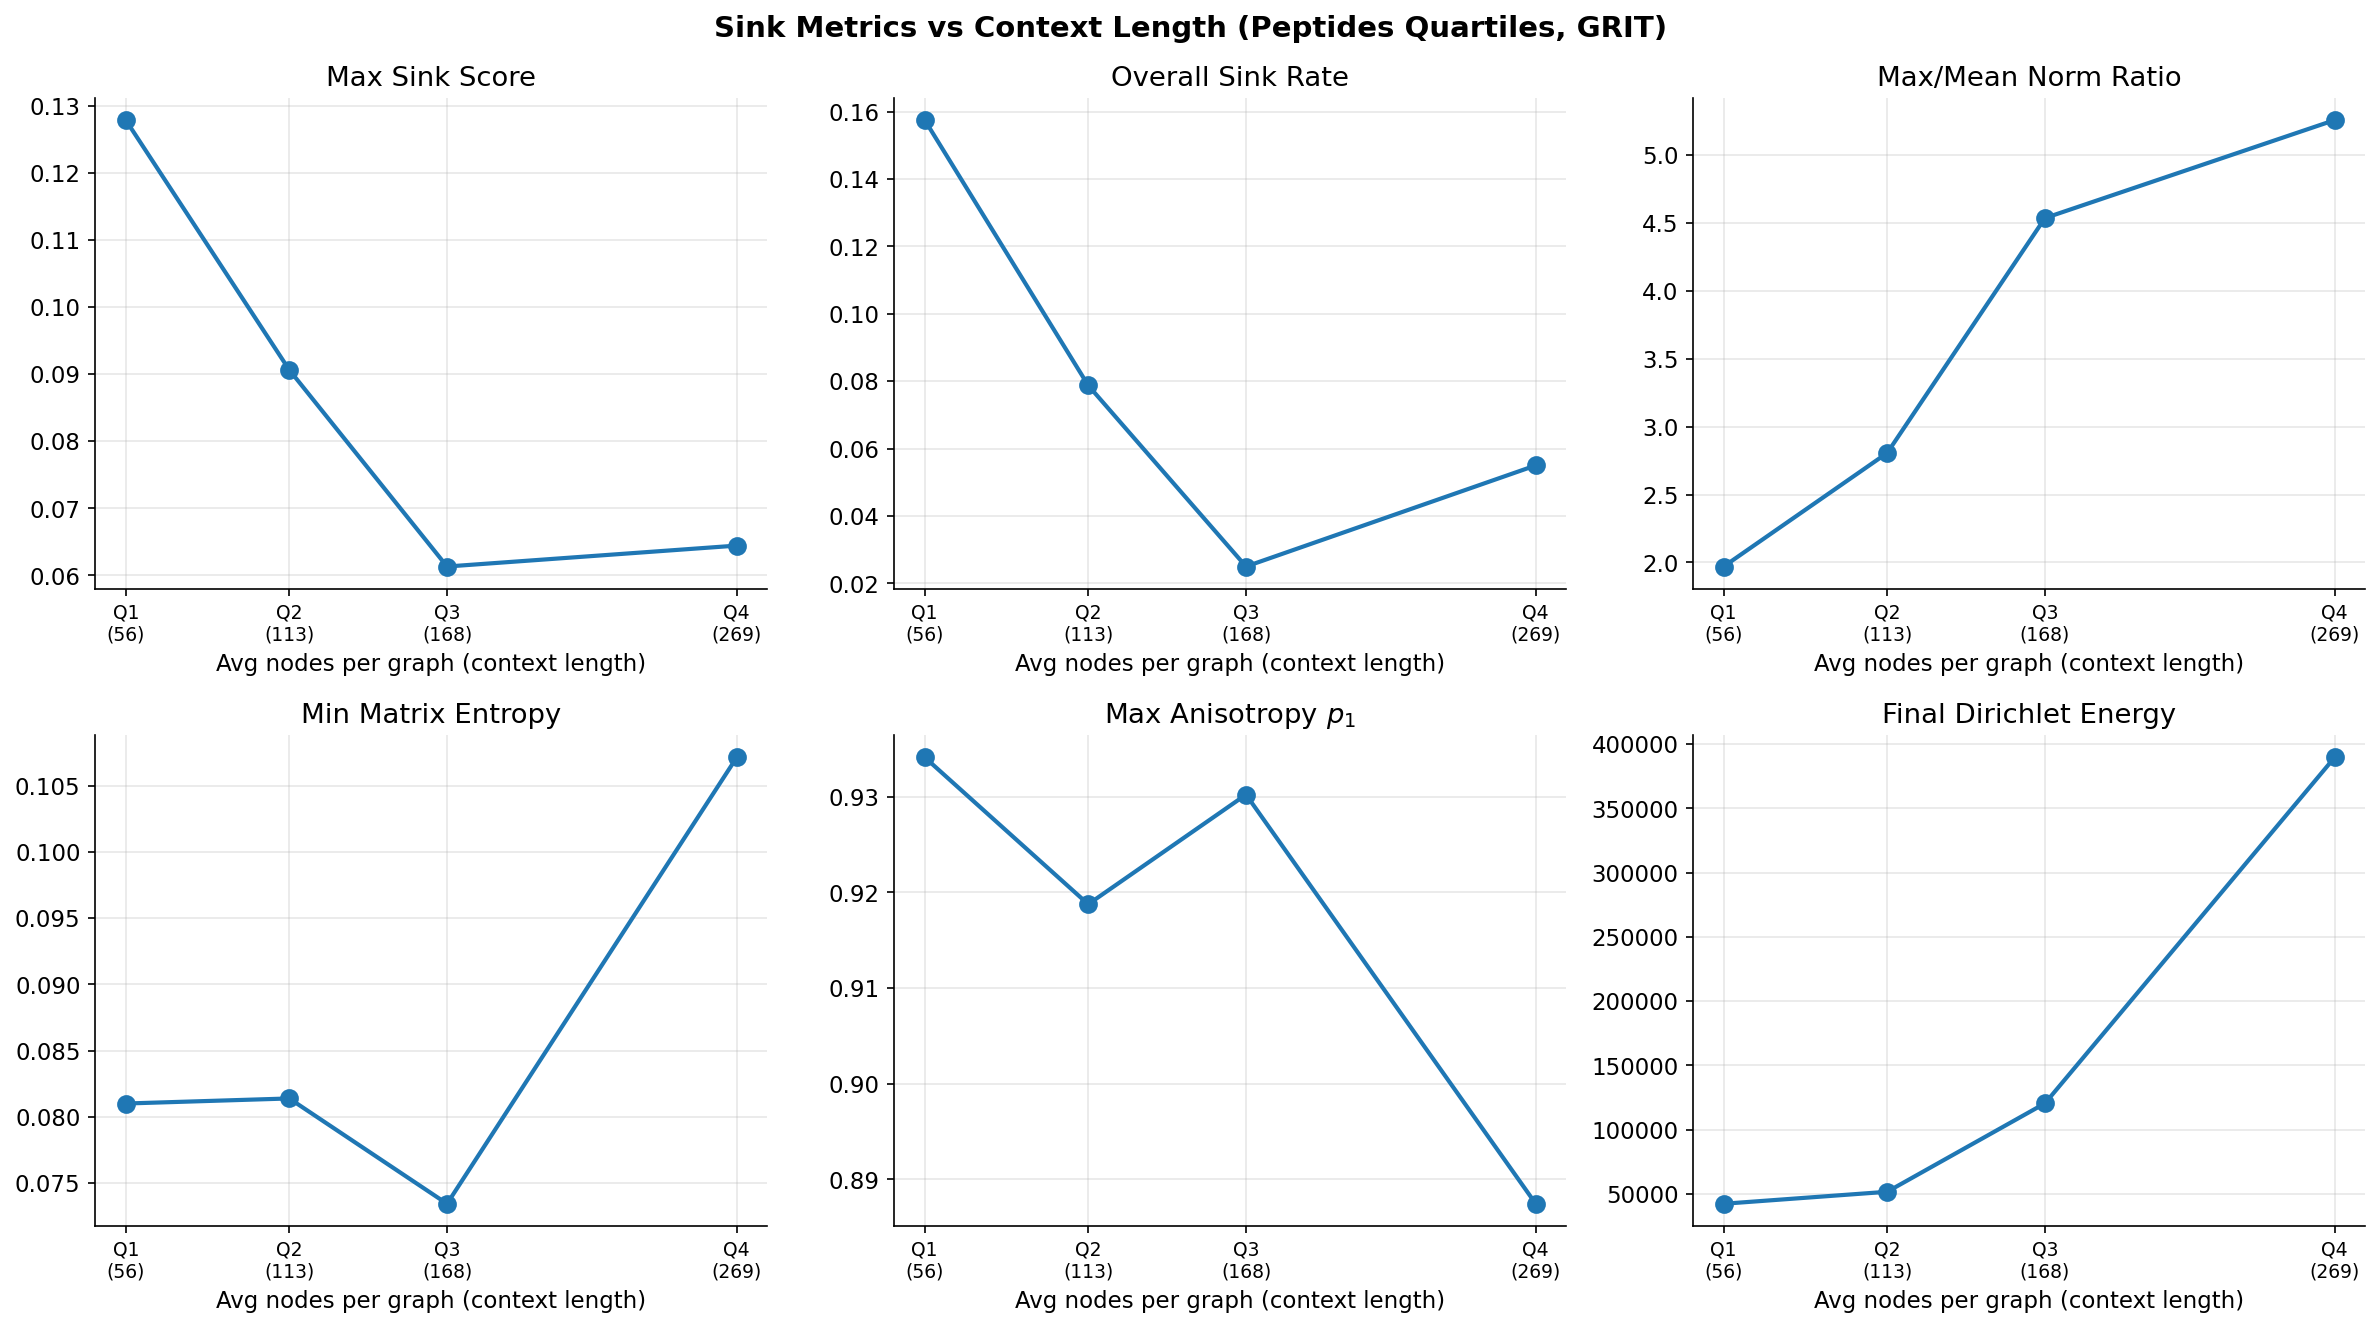

Saved: fig1_context_length.pdf


In [4]:
quartile_ids = [eid for eid, r in results.items() if r['group'] == 'quartile']
quartile_nodes = [results[eid]['avg_nodes'] for eid in quartile_ids]

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Sink Metrics vs Context Length (Peptides Quartiles, GRIT)', fontsize=14, fontweight='bold')

metrics_config = [
    ('max_sink_score', 'Max Sink Score', 'max'),
    ('overall_sink_rate', 'Overall Sink Rate', 'max'),
    ('max_to_mean_ratio', 'Max/Mean Norm Ratio', 'max'),
    ('matrix_entropy', 'Min Matrix Entropy', 'min'),
    ('anisotropy', 'Max Anisotropy $p_1$', 'max'),
    ('dirichlet_energy', 'Final Dirichlet Energy', 'last'),
]

for ax, (metric, title, reducer) in zip(axes.flat, metrics_config):
    vals = []
    for eid in quartile_ids:
        agg = results[eid]['agg']
        if metric in agg:
            arr = agg[metric]['mean']
            if reducer == 'max':
                vals.append(np.nanmax(arr))
            elif reducer == 'min':
                vals.append(np.nanmin(arr))
            elif reducer == 'last':
                valid = arr[~np.isnan(arr)]
                vals.append(valid[-1] if len(valid) > 0 else np.nan)
        else:
            vals.append(np.nan)
    
    ax.plot(quartile_nodes, vals, 'o-', color='tab:blue', linewidth=2, markersize=8)
    ax.set_xlabel('Avg nodes per graph (context length)')
    ax.set_title(title)
    ax.grid(True, alpha=0.3)
    ax.set_xticks(quartile_nodes)
    ax.set_xticklabels([f'Q{i+1}\n({n})' for i, n in enumerate(quartile_nodes)], fontsize=9)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig1_context_length.pdf'), bbox_inches='tight', dpi=150)
plt.show()
print('Saved: fig1_context_length.pdf')

## 4. Fig 2: Layer-wise diagnostics per quartile

Overlay all 4 quartiles on the same 6-panel plot.

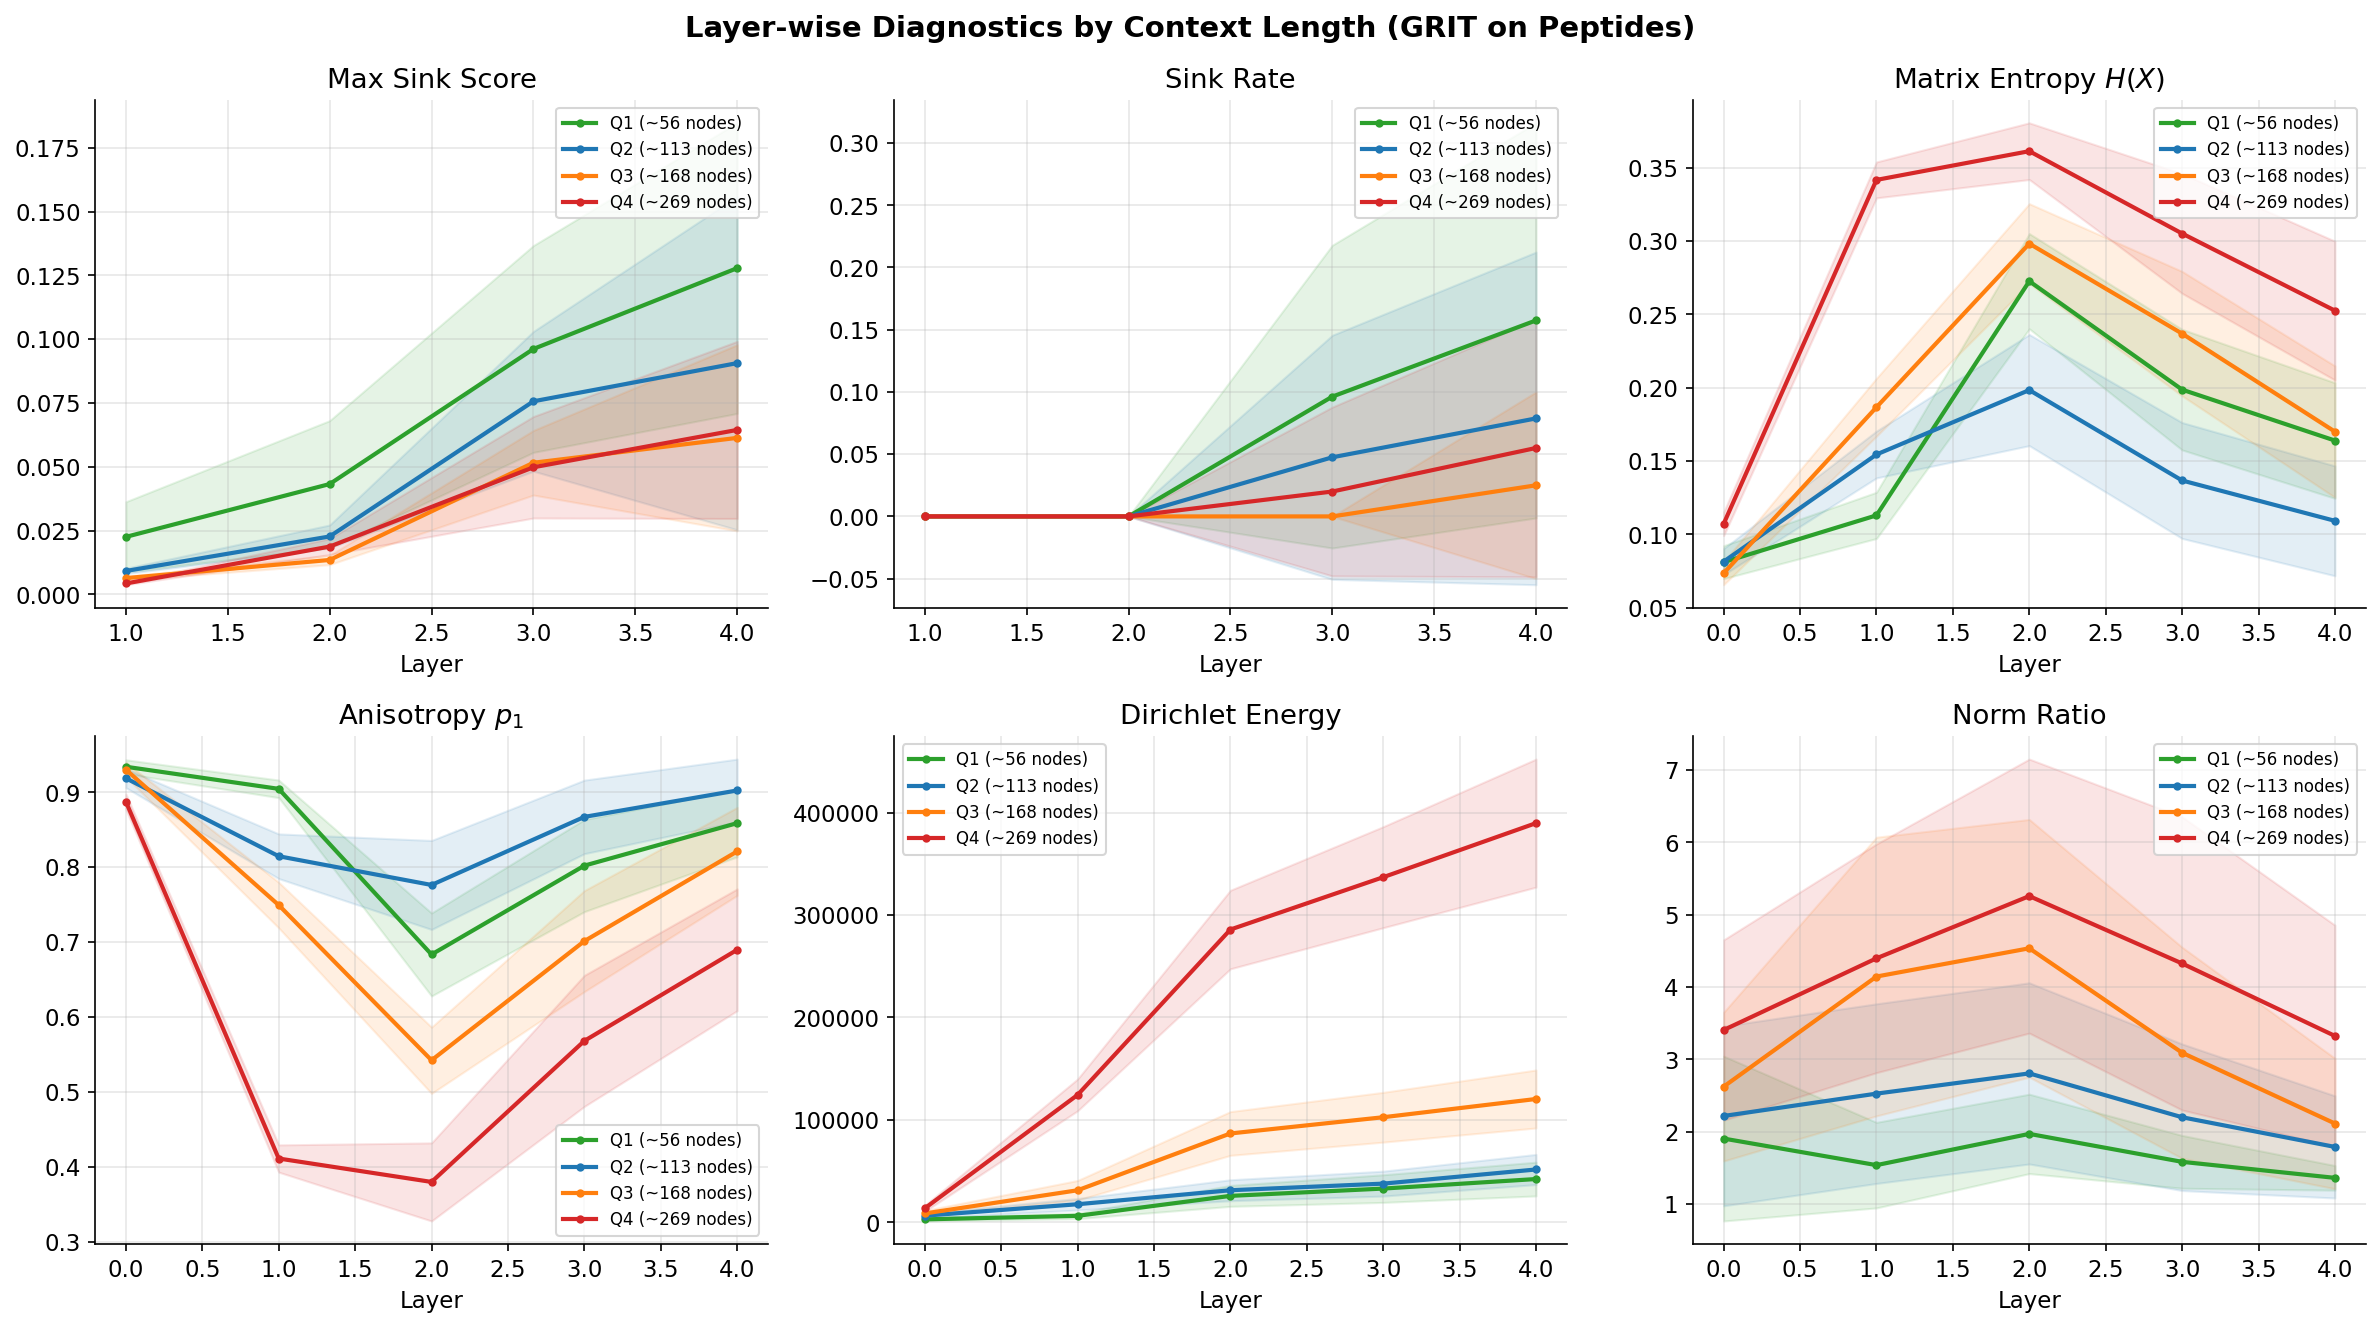

In [5]:
metric_panels = [
    ('max_sink_score', 'Max Sink Score'),
    ('overall_sink_rate', 'Sink Rate'),
    ('matrix_entropy', 'Matrix Entropy $H(X)$'),
    ('anisotropy', 'Anisotropy $p_1$'),
    ('dirichlet_energy', 'Dirichlet Energy'),
    ('max_to_mean_ratio', 'Norm Ratio'),
]

colors = ['tab:green', 'tab:blue', 'tab:orange', 'tab:red']

fig, axes = plt.subplots(2, 3, figsize=(16, 9))
fig.suptitle('Layer-wise Diagnostics by Context Length (GRIT on Peptides)', fontsize=14, fontweight='bold')

for ax, (metric_name, title) in zip(axes.flat, metric_panels):
    for i, eid in enumerate(quartile_ids):
        r = results[eid]
        if metric_name in r['agg']:
            mean = r['agg'][metric_name]['mean']
            std = r['agg'][metric_name]['std']
            layers = np.array(r['layers'])
            valid = ~np.isnan(mean)
            label = f'Q{i+1} (~{r["avg_nodes"]} nodes)'
            ax.plot(layers[valid], mean[valid], color=colors[i], linewidth=2,
                    marker='o', markersize=3, label=label)
            ax.fill_between(layers[valid], (mean - std)[valid], (mean + std)[valid],
                           alpha=0.12, color=colors[i])
    ax.set_xlabel('Layer')
    ax.set_title(title)
    ax.legend(fontsize=8)
    ax.grid(True, alpha=0.3)

plt.tight_layout()
plt.savefig(os.path.join(FIGURES_DIR, 'fig2_layers_quartiles.pdf'), bbox_inches='tight', dpi=150)
plt.show()

## 5. Fig 3: VNode effect on ZINC

Skipping Peptides (~150 nodes) — missing results


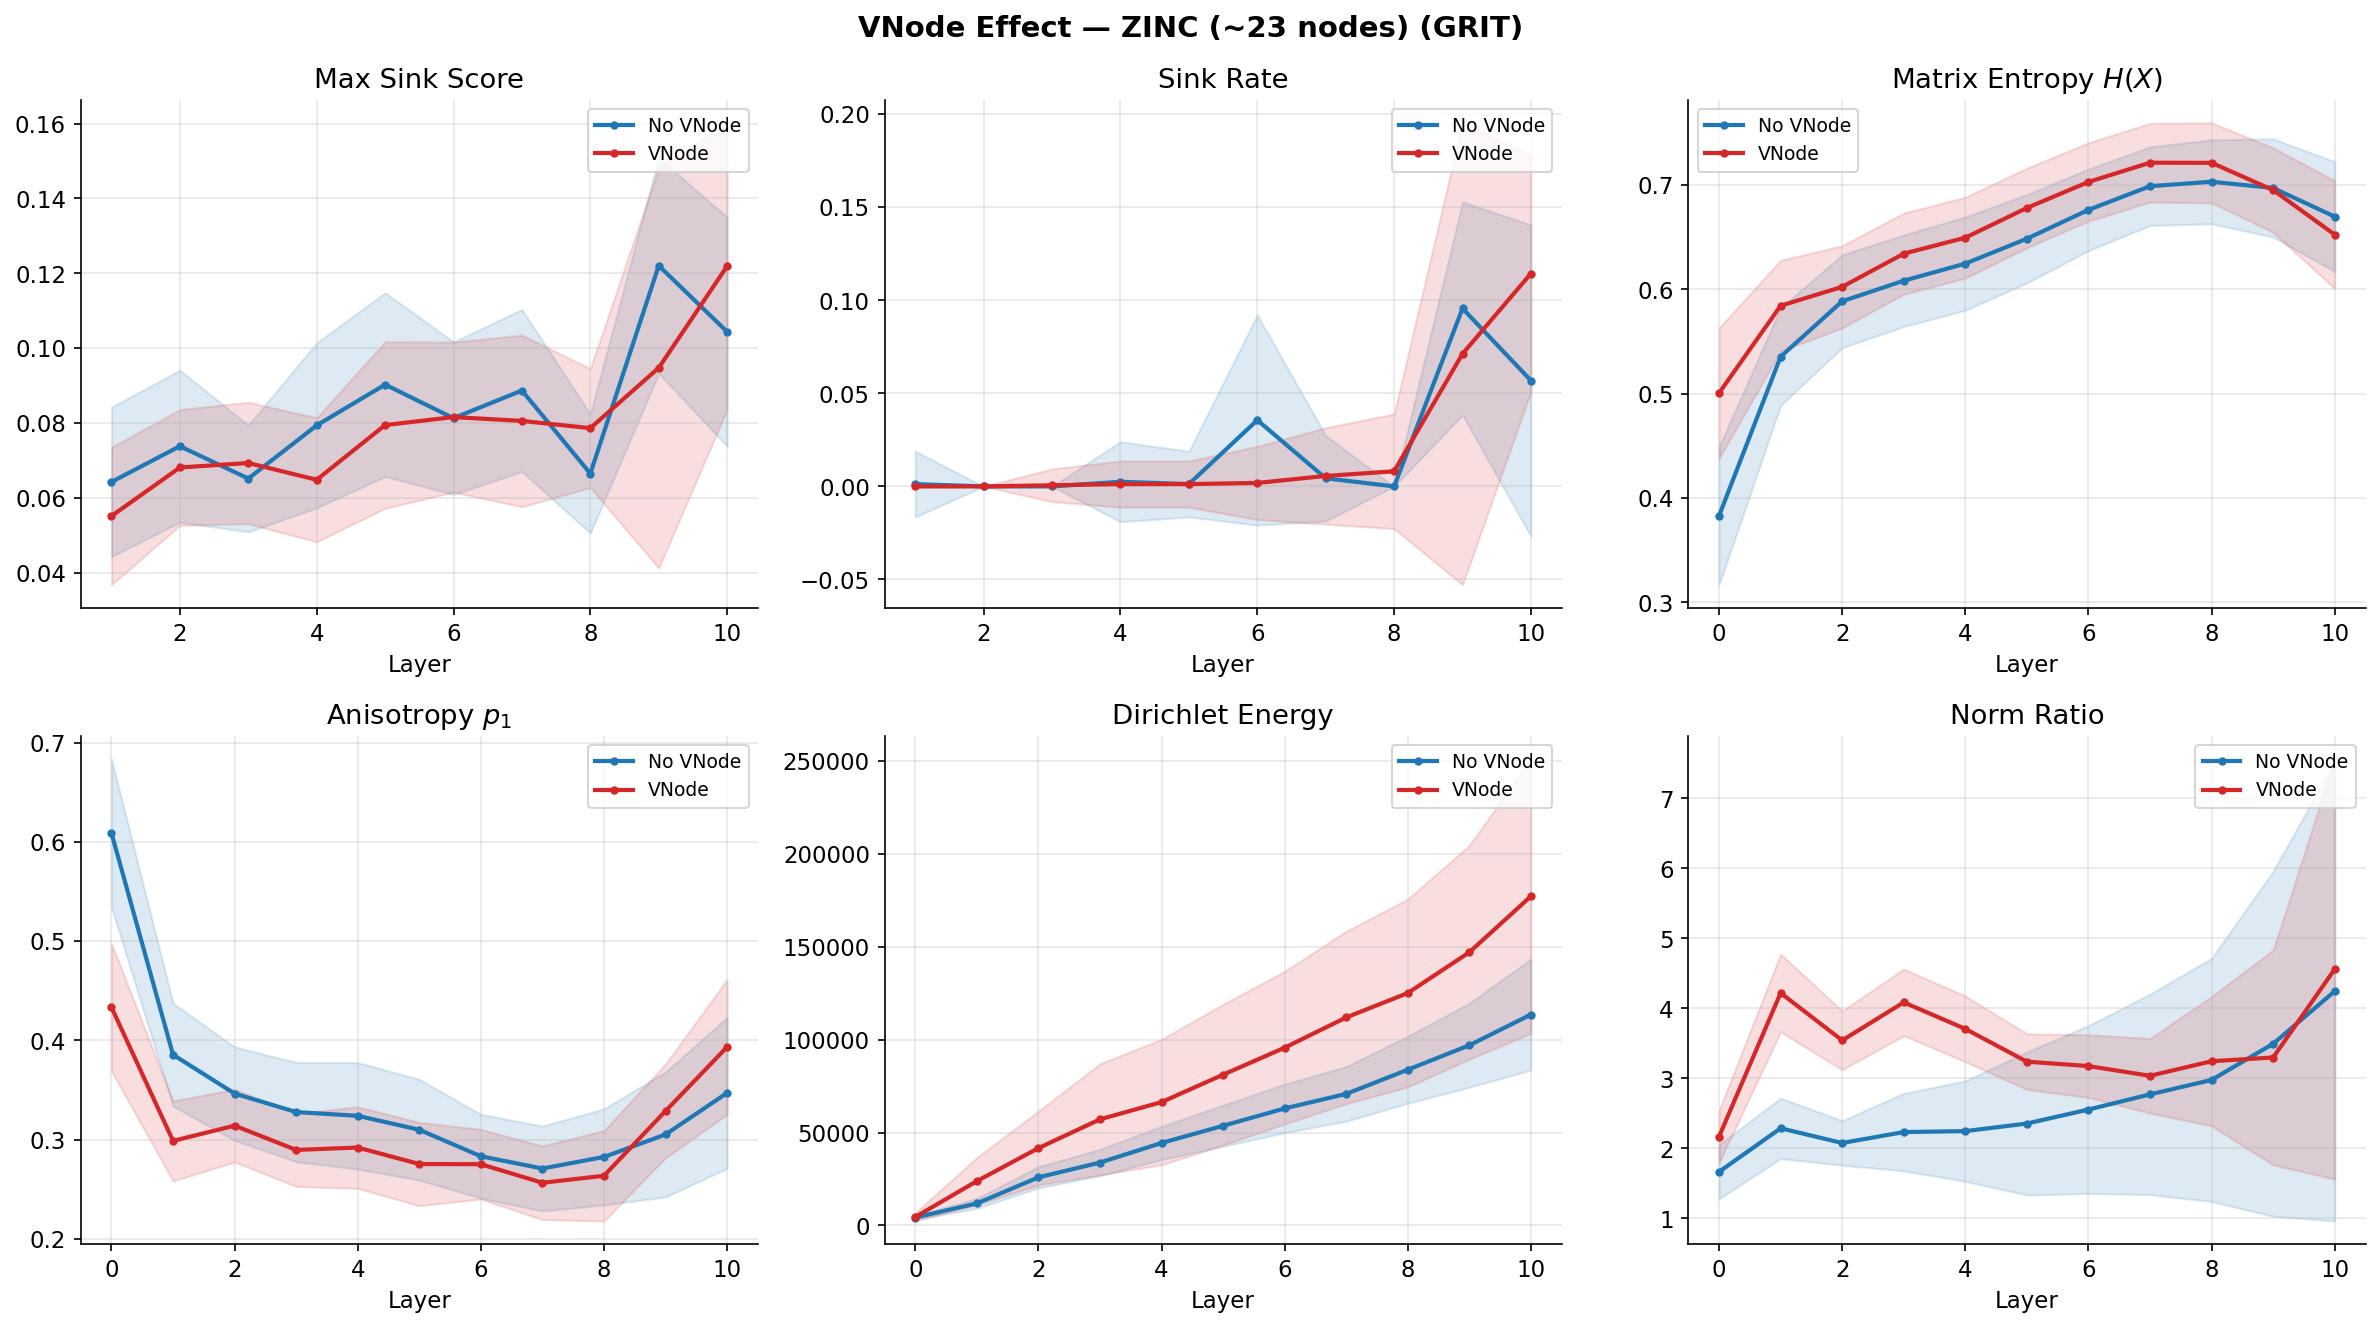

In [6]:
vnode_pairs = [
    ('peptides-grit', 'peptides-grit-vnode', 'Peptides (~150 nodes)'),
    ('zinc-grit', 'zinc-grit-vnode', 'ZINC (~23 nodes)'),
]

for novn_id, vn_id, title in vnode_pairs:
    if novn_id not in results or vn_id not in results:
        print(f'Skipping {title} — missing results')
        continue
    
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle(f'VNode Effect — {title} (GRIT)', fontsize=14, fontweight='bold')
    
    for ax, (metric_name, mtitle) in zip(axes.flat, metric_panels):
        for eid, color, label in [(novn_id, 'tab:blue', 'No VNode'),
                                   (vn_id, 'tab:red', 'VNode')]:
            r = results[eid]
            if metric_name in r['agg']:
                mean = r['agg'][metric_name]['mean']
                std = r['agg'][metric_name]['std']
                layers = np.array(r['layers'])
                valid = ~np.isnan(mean)
                ax.plot(layers[valid], mean[valid], color=color, linewidth=2,
                        marker='o', markersize=3, label=label)
                ax.fill_between(layers[valid], (mean - std)[valid], (mean + std)[valid],
                               alpha=0.15, color=color)
        ax.set_xlabel('Layer')
        ax.set_title(mtitle)
        ax.legend(fontsize=9)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, f'fig3_vnode_zinc.pdf'), bbox_inches='tight', dpi=150)
    plt.show()

## 6. Fig 4: ZINC vs Peptides layer-wise comparison

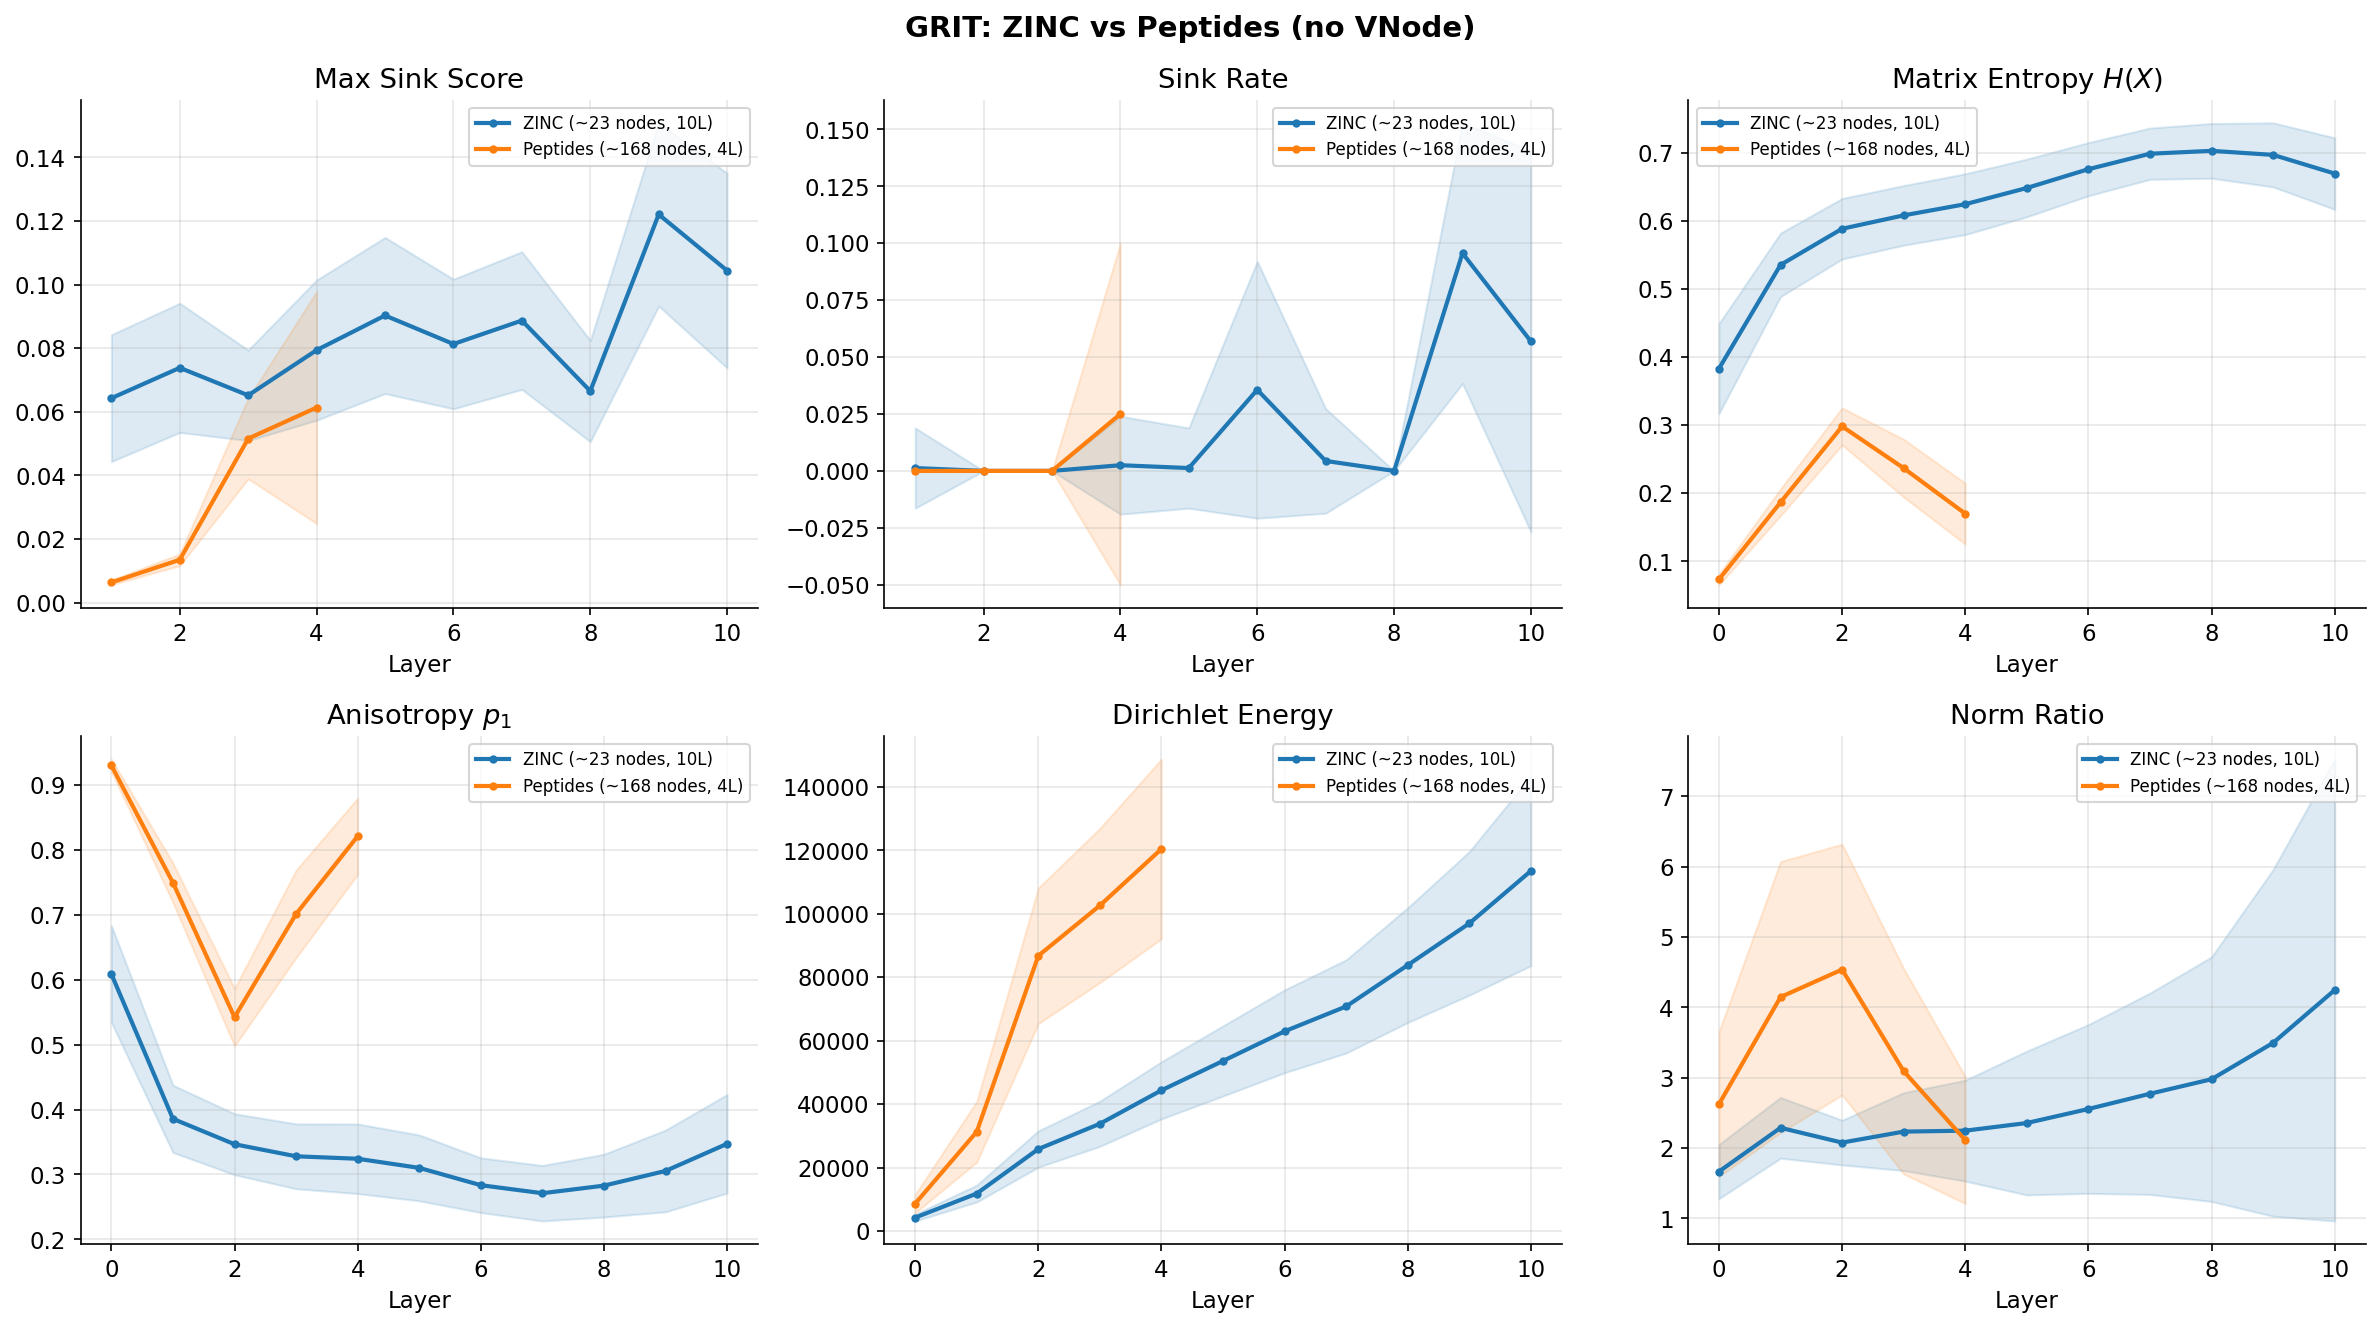

In [7]:
dataset_novnode = [
    ('zinc-grit', 'ZINC (~23 nodes, 10L)'),
    ('peptides-grit-Q3', 'Peptides (~168 nodes, 4L)'),
]

available = [(eid, desc) for eid, desc in dataset_novnode if eid in results]
if len(available) >= 2:
    fig, axes = plt.subplots(2, 3, figsize=(16, 9))
    fig.suptitle('GRIT: ZINC vs Peptides (no VNode)', fontsize=14, fontweight='bold')
    ds_colors = ['tab:blue', 'tab:orange']
    
    for ax, (metric_name, mtitle) in zip(axes.flat, metric_panels):
        for (eid, desc), color in zip(available, ds_colors):
            r = results[eid]
            if metric_name in r['agg']:
                mean = r['agg'][metric_name]['mean']
                std = r['agg'][metric_name]['std']
                layers = np.array(r['layers'])
                valid = ~np.isnan(mean)
                ax.plot(layers[valid], mean[valid], color=color, linewidth=2,
                        marker='o', markersize=3, label=desc)
                ax.fill_between(layers[valid], (mean - std)[valid], (mean + std)[valid],
                               alpha=0.15, color=color)
        ax.set_xlabel('Layer')
        ax.set_title(mtitle)
        ax.legend(fontsize=8)
        ax.grid(True, alpha=0.3)
    
    plt.tight_layout()
    plt.savefig(os.path.join(FIGURES_DIR, 'fig4_layers_zinc_vs_peptides.pdf'), bbox_inches='tight', dpi=150)
    plt.show()